# **社群媒體分析期末專案：**

**課程：** 社群媒體分析  
**教授：** 黃三益 老師  
**組別：** 第三組  
**組員：** 林佩蓉 N124320015、林㛄婷 N134020008、林曉君 N134320024、黃瀞儀 N134320032

---

## 法人交易資訊下的 PTT 討論熱點轉移——個股、ETF 與投資主題的共現分析

### 0. 分析摘要

#### 研究主題

法人交易資訊下的 PTT 討論熱點轉移：個股、ETF 與投資主題的共現分析

#### 核心研究問題

- RQ1：哪些個股、ETF 與投資主題經常被共同提及？
- RQ2：共現網路中有哪些主要核心節點與討論群聚？
- RQ3：不同月份樣本中的討論熱點是否有所變化？

### 1. 研究動機與分析目的

##### 1.1 研究動機

法人買賣超榜單以單一股票或 ETF 為單位呈現，但 PTT 使用者在討論時，往往會同時提及相關股票、ETF 或投資主題。

例如：

* 南亞科
* 華邦電
* 記憶體

可能同時出現在同一位使用者的留言中。

因此，除了觀察哪些標的被提及最多之外，也希望了解：

* 使用者如何連結不同標的
* 哪些主題形成討論核心
* 討論熱點是否隨時間產生變化

#### 1.2 分析目的

本研究有四個目的：

1. 找出 PTT 中最常被共同提及的個股、ETF 與投資主題。
2. 建立共現網路，辨識主要核心節點及主題群聚。
3. 比較不同月份樣本中的討論熱點與實體類型變化。
4. 比較法人 ETF 交易占比與 PTT ETF 討論占比是否呈現相似變化。

### 2. 資料集描述
#### 2.1 資料來源

本研究原始資料來源為PTT Stock版，以`上市買賣超`為關鍵字，以TarFlow爬取 `2026/01/01 ~ 2026/06/01` 間的貼文，取得
- \[情報\]{日期}上市投信買賣超排行
- \[情報\]{日期}上市外資買賣超排行
兩類型資料後再整理成以下：

**法人買賣超資料**

檔案：`net_buy_sell_with_entity_type.csv`

| 欄位          | 說明          |
| ----------- | ----------- |
| system_id   | TarFlow編輯之文章流水號 |
| stock_id   | 股票代碼  |
| stock_name  | 實體名稱 |
| transAmount | 交易量   |
| transType   | 買/賣    |
| transDate   | 交易日   |
| investor    | 投信/外資 |
| entity_type | 個股、ETF、投資主題 |

用途：
* 外資與投信買賣超資訊
* 買賣方向
* 買賣超張數
* 排名

**實體提及資料**

將推文部分擷取出，並透過斷詞處理找出推文提到的個股名稱。

檔案：`comment_stock_mentions_with_entity_type.csv`

用途：

* 每筆留言提及的實體
* entity_type 分類

#### 2.2 本研究主要使用資料

主要分析資料：`comment_stock_mentions_with_entity_type.csv`

欄位：

| 欄位          | 說明          |
| ----------- | ----------- |
| cmtPoster   | 推文者         |
| transDate   | 日期          |
| cmtStatus   | 推、噓、箭頭      |
| stock_name  | 實體名稱        |
| entity_type | 個股、ETF、投資主題 |

#### 2.3 資料摘要

* 資料筆數
* 日期範圍
* 不重複交易日數
* 不重複使用者數
* 不重複實體數
* entity_type 分布
* 各月份實際觀察日數

#### 2.4 資料限制

本研究資料：

* 僅涵蓋 27 個特定交易日
* 非完整連續交易日
* 僅來自法人買賣超文章下留言
* 無法代表整個 PTT Stock 板
* 月份比較僅反映樣本期間


In [7]:
# 載入套件和系統參數
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "output" / "ptt_cooccurrence"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MENTIONS_FILE = DATA_DIR / "comment_stock_mentions_with_entity_type.csv"
NET_BUY_SELL_FILE = DATA_DIR / "net_buy_sell_with_entity_type.csv"

TYPE_ORDER = ["stock", "ETF", "theme"]
TYPE_LABEL = {"stock": "個股", "ETF": "ETF", "theme": "投資主題"}
TYPE_COLOR = {"stock": "#4C78A8", "ETF": "#F58518", "theme": "#54A24B"}

# 網路圖門檻；若圖太密可提高，若節點太少可降低。
# 網路內容篩選參數
MIN_NODE_MENTIONS = 10
MIN_EDGE_WEIGHT = 5
TOP_N_ENTITIES = 15
TOP_N_PAIRS = 10
HOTSPOT_COUNT = 8

RANDOM_SEED = 42



sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Noto Sans CJK TC",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

In [8]:
def save_and_show(filename: str) -> None:
    """統一調整版面、儲存圖檔並顯示。"""
    plt.tight_layout()
    #plt.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


def print_section(title: str) -> None:
    print(f"\n{'=' * 12} {title} {'=' * 12}")

### 3. 分析資料確認與變數設定

#### 3.1 載入資料

載入：

- `comment_stock_mentions_with_entity_type.csv`
- `net_buy_sell_with_entity_type.csv`

#### 3.2 日期轉換與月份欄位

建立：
```text
month
```
供月份比較使用。

#### 3.3 entity_type 分布確認
確認：
* stock
* ETF
* theme

比例與數量。

#### 3.4 聲量定義

本研究定義：

> 一個「日期－使用者－實體」組合作為一次提及事件。

例如：

`2026-03-05, userA, 台積電`

為一次提及事件。

#### 3.5 共現定義

定義：

> 同一位使用者在同一天提到兩個不同實體，即形成一次共現關係。

例如：

`使用者A, 南亞科 華邦電 記憶體`

形成：

```text
南亞科－華邦電
南亞科－記憶體
華邦電－記憶體
```


In [9]:
mentions_raw = pd.read_csv(MENTIONS_FILE)
net_raw = pd.read_csv(NET_BUY_SELL_FILE, dtype={"stock_id": "string"})

mentions = mentions_raw.copy()
net = net_raw.copy()

mentions["transDate"] = pd.to_datetime(mentions["transDate"], errors="coerce")
net["transDate"] = pd.to_datetime(net["transDate"], errors="coerce")
mentions = mentions.dropna(subset=["cmtPoster", "transDate", "stock_name", "entity_type"])
net = net.dropna(
    subset=["transDate", "stock_id", "stock_name", "investor", "entity_type"]
)

# 將原始中文 entity_type 統一為分析用英文代碼。
type_map = {
    "個股": "stock",
    "stock": "stock",
    "ETF": "ETF",
    "etf": "ETF",
    "投資主題": "theme",
    "主題": "theme",
    "theme": "theme",
}
mentions["entity_type"] = mentions["entity_type"].astype(str).str.strip().map(type_map)

# 統一標籤格式。
net["entity_type"] = net["entity_type"].astype(str).str.strip().map(type_map)

mentions["stock_name"] = mentions["stock_name"].astype(str).str.strip()
mentions["cmtPoster"] = mentions["cmtPoster"].astype(str).str.strip()
mentions["month"] = mentions["transDate"].dt.to_period("M").astype(str)
net["month"] = net["transDate"].dt.to_period("M").astype(str)

# 步驟 3.4：一個「日期－使用者－實體」組合只算一次提及事件。
mention_events = mentions.drop_duplicates(
    subset=["transDate", "cmtPoster", "stock_name"]
).copy()

# 步驟 3.4：一個「日期－使用者－實體」組合只算一次提及事件。
mention_events = mentions.drop_duplicates(
    subset=["transDate", "cmtPoster", "stock_name"]
).copy()

# 同名實體若被標成多種類型，採用資料中最常見的類型並列出警告。
entity_type_counts = (
    mention_events.groupby(["stock_name", "entity_type"]).size().rename("n").reset_index()
)
entity_type_lookup = (
    entity_type_counts.sort_values(["stock_name", "n"], ascending=[True, False])
    .drop_duplicates("stock_name")
    .set_index("stock_name")["entity_type"]
    .to_dict()
)

In [10]:

# 步驟 2.3：資料摘要。
data_summary = pd.Series(
    {
        "原始資料筆數": len(mentions_raw),
        "去重後提及事件數": len(mention_events),
        "起始日期": mention_events["transDate"].min().date(),
        "結束日期": mention_events["transDate"].max().date(),
        "不重複交易日數": mention_events["transDate"].nunique(),
        "不重複使用者數": mention_events["cmtPoster"].nunique(),
        "不重複實體數": mention_events["stock_name"].nunique(),
    },
    name="資料摘要",
)
print_section("資料摘要")
print(data_summary)



============ 資料摘要 ============
原始資料筆數            4766
去重後提及事件數          4726
起始日期        2026-01-02
結束日期        2026-05-29
不重複交易日數             27
不重複使用者數           1578
不重複實體數             252
Name: 資料摘要, dtype: object


In [11]:
monthly_observation_days = (
    mention_events.groupby("month")["transDate"]
    .nunique()
    .rename("觀察日數")
    .to_frame()
)
print("各月份實際觀察日數：")
print(monthly_observation_days)


各月份實際觀察日數：
         觀察日數
month        
2026-01     6
2026-02     3
2026-03    10
2026-04     2
2026-05     6


### 4. 描述性分析：整體討論熱點

#### 圖 1：熱門實體前 15 名

指標：`提及事件數`

目的：
找出整體最熱門的：
* 個股
* ETF
* 投資主題

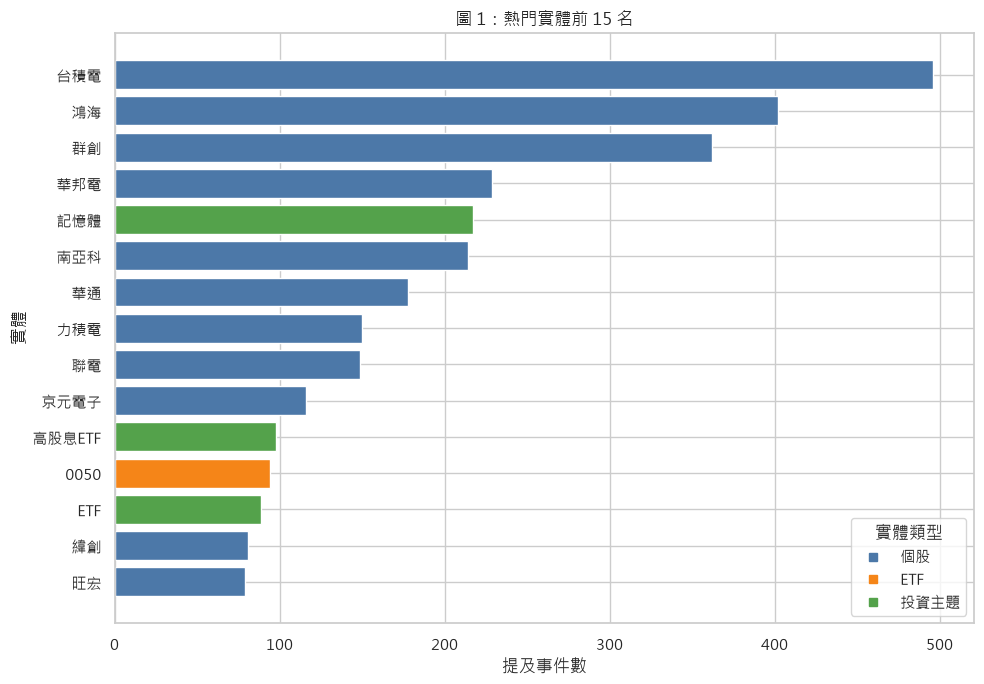

In [12]:
entity_mentions = mention_events["stock_name"].value_counts().rename("mention_count")
top_entities = entity_mentions.head(TOP_N_ENTITIES).sort_values()
top_entity_types = [entity_type_lookup[name] for name in top_entities.index]

plt.figure(figsize=(10, 7))
plt.barh(
    top_entities.index,
    top_entities.values,
    color=[TYPE_COLOR[t] for t in top_entity_types],
)
plt.xlabel("提及事件數")
plt.ylabel("實體")
plt.title(f"圖 1：熱門實體前 {TOP_N_ENTITIES} 名")
legend_handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", color=TYPE_COLOR[t], label=TYPE_LABEL[t])
    for t in TYPE_ORDER
]
plt.legend(handles=legend_handles, title="實體類型", loc="lower right")
save_and_show("figure_1_top_entities.png")


從熱門實體排名可以發現，討論焦點主要集中於少數大型個股與熱門產業題材。其中台積電與鴻海為提及次數最高的兩檔個股，顯示權值股仍是法人買賣超討論的重要核心。另一方面，華邦電、南亞科以及「記憶體」皆進入前 15 名，顯示使用者除了討論個別股票外，也會透過產業主題來理解市場資訊。此結果支持後續進行共現分析的必要性，因為使用者的討論可能並非以單一股票為單位，而是圍繞產業與投資主題形成群聚結構。
群創為本研究中討論度第三高的個股，顯示其在樣本期間受到使用者高度關注。至於受到關注的原因，可能與面板產業議題或個股表現有關，但本研究資料無法進一步驗證。

#### 圖 2：實體類型提及占比

比較：
* 個股
* ETF
* 投資主題

目的：了解整體討論重心。


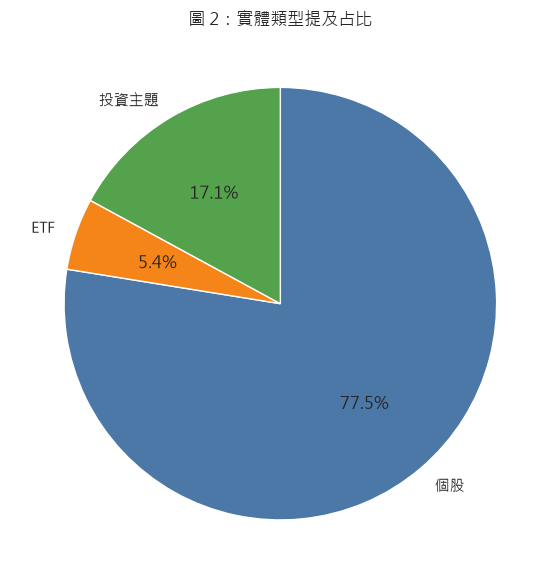

In [13]:
# 圖 2：實體類型提及占比。
type_counts = mention_events["entity_type"].value_counts().reindex(TYPE_ORDER, fill_value=0)
plt.figure(figsize=(7, 6))
plt.pie(
    type_counts.values,
    labels=[TYPE_LABEL[t] for t in type_counts.index],
    colors=[TYPE_COLOR[t] for t in type_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
plt.title("圖 2：實體類型提及占比")
save_and_show("figure_2_entity_type_share.png")

雖然個股占所有提及事件的77.5%，但投資主題仍占 17.1%，顯示使用者並非完全以個別股票進行討論。因此後續將進一步透過共現分析，探討個股、ETF 與投資主題之間的連結關係，以及投資主題是否在討論網路中扮演重要的橋接角色。

### 5. 整體共現網路分析（主分析）

#### 5.1 建立共現配對

依照：`transDate + cmtPoster`分組。
建立：`entity_a`, `entity_b`,`weight`共現表。


In [14]:
pair_counter: Counter[tuple[str, str]] = Counter()
for _, group in mention_events.groupby(["transDate", "cmtPoster"], sort=False):
    entities = sorted(group["stock_name"].unique())
    pair_counter.update(combinations(entities, 2))

cooccurrence = pd.DataFrame(
    [(a, b, weight) for (a, b), weight in pair_counter.items()],
    columns=["entity_a", "entity_b", "weight"],
).sort_values("weight", ascending=False, ignore_index=True)

print(cooccurrence.head(20))
#cooccurrence.to_csv(OUTPUT_DIR / "cooccurrence_all.csv", index=False, encoding="utf-8-sig")


   entity_a entity_b  weight
0       南亞科      華邦電      43
1        友達       群創      29
2       台積電       鴻海      28
3      0050      台積電      21
4       南亞科      記憶體      17
5       台積電   高股息ETF      11
6       力積電      台積電      10
7       力積電      華邦電      10
8        聯電       鴻海       9
9    主動式ETF      台積電       9
10      華邦電      記憶體       9
11       廣達       鴻海       9
12       緯創       鴻海       9
13       群創       面板       9
14   00981A      台積電       8
15      ETF   主動式ETF       8
16       群創       鴻海       8
17      台積電      金融股       8
18      ETF      台積電       8
19       群創      記憶體       8


從結果可以發現，高頻共現關係並非隨機出現，而是呈現明顯的主題群聚特徵。進一步觀察後，可將主要共現關係分為產業群聚、ETF 與成分股群聚，以及權值股群聚三種類型。

**（一）產業群聚：使用者傾向以產業角度討論個股**

共現次數最高的配對為南亞科與華邦電（43 次），同時南亞科與「記憶體」共現 17 次，華邦電與「記憶體」共現 9 次。

南亞科與華邦電皆屬於記憶體產業，因此使用者在討論其中一家公司時，經常同時提及另一家公司或整體記憶體產業。這表示使用者並非只關注個別股票，而是將股票放在產業脈絡中理解。

類似現象也出現在面板產業。友達與群創的共現次數達 29 次，而群創與「面板」主題亦有明顯連結。由於友達與群創皆屬於面板產業，因此討論常同時涉及競爭公司與整體產業發展。

上述結果顯示，PTT 使用者在討論法人買賣超資訊時，經常以產業作為理解市場的重要框架，並形成以產業為核心的討論群聚。

**（二）ETF 與成分股群聚：使用者透過 ETF 理解個股**

除了產業群聚之外，共現結果也呈現 ETF 與成分股之間的連結。

其中，0050 與台積電的共現次數達 21 次，是所有 ETF 相關配對中最明顯的組合。此外，台積電也同時出現在主動式 ETF、高股息 ETF 以及 ETF 等相關配對之中。

此現象顯示，使用者在討論 ETF 時，經常同時提及其代表性成分股，而台積電作為台灣市場最具代表性的權值股，自然成為 ETF 討論的重要參照標的。

值得注意的是，「高股息ETF－台積電」也出現在高頻共現組合中。雖然台積電並非所有高股息 ETF 的主要成分股，但使用者可能在比較不同 ETF 投資策略或解釋 ETF 配置方式時，同時提及台積電，因此形成共現關係。

整體而言，ETF 相關共現關係反映出使用者不僅討論個別股票，也會透過 ETF 作為投資工具來理解市場。

**（三）權值股群聚：市場代表性個股的共同討論**

台積電與鴻海的共現次數達 28 次，為第三高的共現配對。此外，鴻海也與聯電、廣達及緯創等大型電子股形成多組共現關係。

相較於記憶體與面板群聚，這類共現關係較不代表特定產業，而更接近市場代表性個股之間的共同討論現象。由於台積電與鴻海皆屬於台灣股市的重要權值股，因此當使用者討論市場趨勢、法人動向或電子產業時，經常同時提及這些大型企業。

此結果顯示，除了產業關聯之外，市場代表性也是影響共現關係的重要因素。

**（四）其他共現關係**

部分共現配對較難直接由產業關係解釋，例如力積電與台積電（10 次）、力積電與華邦電（10 次）等組合。

這些共現關係可能來自使用者對同類型公司進行比較，或來自特定市場議題與投資討論。然而，僅根據共現資料無法判斷實際討論內容，因此本研究不進一步推論其形成原因。

**小結**

整體共現結果顯示，PTT 使用者並非孤立地討論單一股票，而是透過不同方式將市場資訊組織成主題群聚。

從共現關係來看，主要可分為三種類型：

1. 產業群聚
南亞科－華邦電
友達－群創

2. ETF 與成分股群聚
0050－台積電
ETF－台積電

3. 權值股群聚
台積電－鴻海

這些群聚顯示，使用者在解讀法人買賣超資訊時，除了關注個別標的之外，也會透過產業、ETF 以及市場代表性個股等不同層次建立對市場的理解。此結果也說明，共現分析能夠補充單純聲量統計無法呈現的討論結構與主題關聯。

#### 5.2 篩選節點與連線

依資料情況設定：
* 最低提及次數
* 最低共現次數

避免網路圖過度複雜。


In [15]:
def draw_cooccurrence_network(
    G,
    node_size_by="weighted_degree",
    color_by="entity_type",
    title="整體共現網路圖",
    figsize=(12,9),
    node_min_size=300,
    node_size_scale=100,
    edge_min_width=0.5,
    edge_width_scale=5,
    layout_k=1.2,
    layout_iterations=150,
    label_font_size=9,
    label_min_mentions=10,
    node_alpha=0.9,
    edge_alpha=0.25,
    seed=42
):
    """
    node_size_by:
        mentions：依提及事件數調整節點大小
        weighted_degree：依加權度數調整節點大小

    color_by:
        entity_type：依個股、ETF、投資主題著色
        community：依網路群聚著色
    """

    # 1. 計算節點位置
    pos = nx.spring_layout(
        G,
        weight="weight",
        k=layout_k,
        iterations=layout_iterations,
        seed=seed
    )

    # 2. 設定節點大小
    if node_size_by == "mentions":
        node_values = {
            node: G.nodes[node]["mentions"]
            for node in G.nodes
        }

    elif node_size_by == "weighted_degree":
        node_values = dict(G.degree(weight="weight"))

    else:
        raise ValueError(
            'node_size_by 必須是 "mentions" 或 "weighted_degree"'
        )

    node_sizes = [
        node_min_size
        + np.sqrt(node_values[node]) * node_size_scale
        for node in G.nodes
    ]

    # 3. 設定節點顏色及圖例
    if color_by == "entity_type":
        node_colors = [
            TYPE_COLOR[G.nodes[node]["entity_type"]]
            for node in G.nodes
        ]

        present_types = {
            G.nodes[node]["entity_type"]
            for node in G.nodes
        }

        legend_handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=10,
                markerfacecolor=TYPE_COLOR[entity_type],
                markeredgecolor="white",
                label=TYPE_LABEL[entity_type]
            )
            for entity_type in TYPE_ORDER
            if entity_type in present_types
        ]

        legend_title = "實體類型"

    elif color_by == "community":
        # 必須先在 5.3 將 community 寫入 G
        missing_community = [
            node
            for node in G.nodes
            if "community" not in G.nodes[node]
        ]

        if missing_community:
            raise ValueError(
                "部分節點沒有 community 屬性，請先執行 5.3 的群聚分析。"
            )

        community_ids = [
            G.nodes[node]["community"]
            for node in G.nodes
        ]

        cmap = plt.colormaps["tab10"]

        community_colors = {
            community_id: cmap((community_id - 1) % 10)
            for community_id in sorted(set(community_ids))
        }

        node_colors = [
            community_colors[community_id]
            for community_id in community_ids
        ]

        legend_handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=10,
                markerfacecolor=community_colors[community_id],
                markeredgecolor="white",
                label=f"群聚 {community_id}"
            )
            for community_id in sorted(community_colors)
        ]

        legend_title = "討論群聚"

    else:
        raise ValueError(
            'color_by 必須是 "entity_type" 或 "community"'
        )

    # 4. 設定連線粗細
    edge_weights = np.array(
        [
            G[u][v].get("weight", 1)
            for u, v in G.edges
        ],
        dtype=float
    )

    max_edge_weight = edge_weights.max() if len(edge_weights) else 1

    edge_widths = (
        edge_min_width
        + edge_weights / max_edge_weight * edge_width_scale
    )

    # 5. 只顯示較重要節點的名稱
    labels = {
        node: node
        for node in G.nodes
        if G.nodes[node]["mentions"] >= label_min_mentions
    }

    # 6. 繪圖
    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_widths,
        edge_color="#808080",
        alpha=edge_alpha
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="white",
        linewidths=1,
        alpha=node_alpha
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=label_font_size,
        font_weight="bold"
    )

    ax.legend(
        handles=legend_handles,
        title=legend_title,
        loc="upper left",
        frameon=True
    )

    ax.set_title(
        f"{title}\n"
        f"節點提及次數 >= {MIN_NODE_MENTIONS}；"
        f"共現次數 >= {MIN_EDGE_WEIGHT}",
        fontsize=15
    )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

節點數： 27
連線數： 42
節點： ['南亞科', '華邦電', '友達', '群創', '台積電', '鴻海', '0050', '記憶體', '高股息ETF', '力積電']
連線： [('南亞科', '華邦電', {'weight': 43}), ('南亞科', '記憶體', {'weight': 17}), ('南亞科', '力積電', {'weight': 7}), ('南亞科', '旺宏', {'weight': 5}), ('南亞科', '群創', {'weight': 5}), ('華邦電', '力積電', {'weight': 10}), ('華邦電', '記憶體', {'weight': 9}), ('華邦電', '台積電', {'weight': 6}), ('華邦電', '鴻海', {'weight': 6}), ('華邦電', '華通', {'weight': 6})]


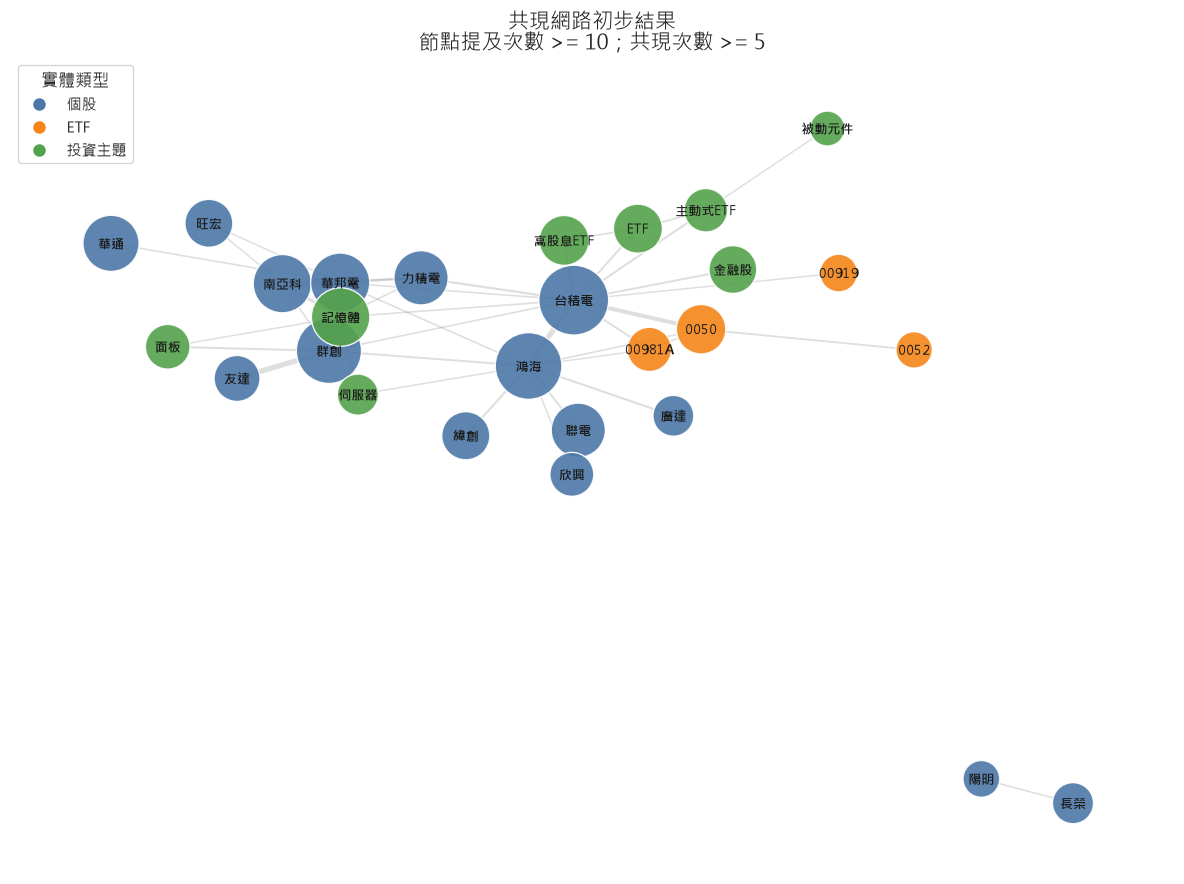

In [16]:
eligible_nodes = set(entity_mentions[entity_mentions >= MIN_NODE_MENTIONS].index)
filtered_edges = cooccurrence[
    cooccurrence["entity_a"].isin(eligible_nodes)
    & cooccurrence["entity_b"].isin(eligible_nodes)
    & (cooccurrence["weight"] >= MIN_EDGE_WEIGHT)
].copy()

if filtered_edges.empty:
    raise ValueError(
        "目前門檻下沒有共現連線，請降低 MIN_NODE_MENTIONS 或 MIN_EDGE_WEIGHT。"
    )

G = nx.from_pandas_edgelist(
    filtered_edges,
    source="entity_a",
    target="entity_b",
    edge_attr="weight",
    create_using=nx.Graph,
)
nx.set_node_attributes(G, {n: int(entity_mentions[n]) for n in G}, "mentions")
nx.set_node_attributes(G, {n: entity_type_lookup[n] for n in G}, "entity_type")

print("節點數：", G.number_of_nodes())
print("連線數：", G.number_of_edges())
print("節點：", list(G.nodes())[:10])
print("連線：", list(G.edges(data=True))[:10])

draw_cooccurrence_network(
    G,
    node_size_by="mentions",
    title="共現網路初步結果"
)

這步驟以節點類型進行分類，其中藍色代表個股、橘色代表 ETF、綠色代表投資主題。整體網路共包含 27 個節點與 42 條連線。

從圖中可以發現，個股占據網路中的大部分節點，與前述實體類型統計結果一致，顯示法人買賣超相關討論仍以個股為主要討論對象。然而，ETF 與投資主題並未完全獨立存在，而是與個股形成大量連結。

其中，台積電位於網路中心位置，同時連結多個 ETF 節點（0050、00981A）以及投資主題節點（ETF、高股息ETF、主動式ETF、金融股），顯示其不僅是高聲量個股，也是不同討論脈絡之間的重要連結點。

此外，記憶體、面板等投資主題也與相關個股形成緊密連結。例如南亞科、華邦電與記憶體之間，以及友達、群創與面板之間皆形成明顯的共現關係。

整體而言，本圖顯示 PTT 使用者在討論法人買賣超資訊時，雖然仍以個股為核心，但會透過 ETF 與投資主題將不同股票連結起來，形成更完整的市場討論脈絡。

#### 5.3 網路指標與群聚分析

本研究使用以下指標描述共現網路：

##### 提及事件數

代表實體在 PTT 留言中的整體聲量。

提及事件數越高，表示該實體在樣本期間被越多「日期－使用者」組合提及。

##### 度數

代表該實體與多少個不同實體產生共現關係。

度數越高，表示該實體與較多不同標的或投資主題產生連結。

##### 加權度數

代表該實體與其他節點共同出現的總次數。

加權度數越高，表示該實體不僅與其他實體有所連結，而且整體共現強度較高，因此可視為共現網路中的核心節點。

##### 討論群聚

本研究使用 Greedy Modularity Community Detection 方法進行群聚分析。

此方法會根據節點之間的共現關係及共現次數，將連結較緊密的實體分到同一群聚。相同群聚中的個股、ETF 或投資主題，代表它們較常出現在相同使用者同一天的討論中。

群聚編號僅用於區分不同群組，不代表排名或重要程度。

#### 圖 3：整體共現網路圖

圖表設定：

- 節點：個股、ETF 或投資主題
- 節點大小：加權度數
- 線條：兩個實體之間的共現關係
- 線條粗細：共現次數
- 節點顏色：所屬討論群聚
- 節點位置：連結越緊密的節點通常越靠近

圖表解讀：

- 較大的節點代表與其他實體共現的總強度較高。
- 較粗的連線代表兩個實體共同出現的次數較多。
- 相同顏色的節點屬於同一討論群聚。
- 位於多個節點之間的實體，可能扮演不同標的或主題之間的連結角色。

分析重點：

1. 找出加權度數較高的核心節點。
2. 觀察各群聚包含哪些個股、ETF 與投資主題。
3. 判斷各群聚可能對應的產業、ETF 或市場議題。
4. 觀察投資主題是否位於群聚核心，或連結不同類型的實體。
5. 比較高聲量節點與高共現強度節點是否相同。

需要注意的是，節點顏色現在代表「討論群聚」，不再代表 `entity_type`。因此，判斷節點屬於個股、ETF 或投資主題時，需搭配網路指標表中的 `entity_type` 欄位。

---

#### 表 1：最強共現配對前 10 名

| 排名 | Entity A | Entity B | 共現次數 |
|---:|---|---|---:|
| 1 | 實體 A | 實體 B | 次數 |

目的：

表格列出共現次數最高的實體配對，用來補充網路圖中不容易精確判讀的連線強度，並協助說明各群聚中的主要討論組合。

表格可用於回答：

- 哪些個股經常被共同討論？
- 哪些 ETF 經常與特定個股共同出現？
- 哪些投資主題與個股或 ETF 具有較強連結？
- 最強共現配對是否位於同一討論群聚？



============ 步驟 5.3 共現網路核心節點 ============
    entity entity_type  mention_count  degree  weighted_degree  community
0      台積電          個股            496      12              126          1
1       鴻海          個股            402      10               90          1
2      華邦電          個股            229       7               85          2
3      南亞科          個股            214       5               77          2
4       群創          個股            362       6               65          3
5      記憶體        投資主題            217       7               56          2
6     0050         ETF             94       4               39          1
7      力積電          個股            150       4               33          2
8       友達          個股             63       1               29          3
9      ETF        投資主題             89       3               22          1
10  主動式ETF        投資主題             46       3               22          1
11  00981A         ETF             51       3               18       

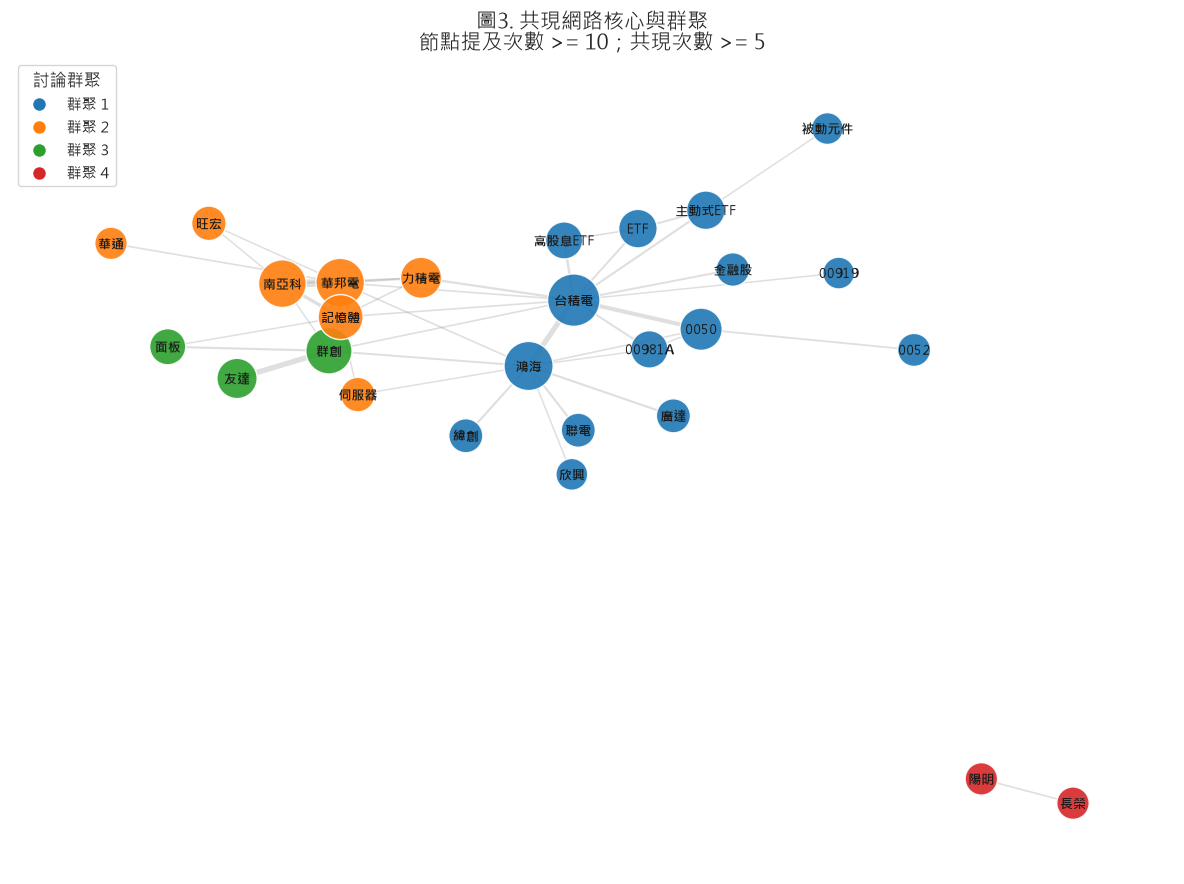


============ 表 1 最強共現配對前 10 名 ============
   排名 Entity A Entity B  共現次數
0   1      南亞科      華邦電    43
1   2       友達       群創    29
2   3      台積電       鴻海    28
3   4     0050      台積電    21
4   5      南亞科      記憶體    17
5   6      台積電   高股息ETF    11
6   7      力積電      台積電    10
7   8      力積電      華邦電    10
8   9       聯電       鴻海     9
9  10   主動式ETF      台積電     9


In [17]:
# 1. 計算節點度數
# degree：與多少個不同實體產生連線
# weighted_degree：所有共現次數的加總
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))

# 2. 使用 greedy modularity 辨識討論群聚
communities = list(
    nx.community.greedy_modularity_communities(
        G,
        weight="weight"
    )
)

community_lookup = {
    node: community_id
    for community_id, nodes in enumerate(communities, start=1)
    for node in nodes
}

# 3. 將網路指標存入節點屬性
# 後續繪圖或查詢節點時可以直接使用
nx.set_node_attributes(G, degree, "degree")
nx.set_node_attributes(G, weighted_degree, "weighted_degree")
nx.set_node_attributes(G, community_lookup, "community")

# 4. 建立節點網路指標表
network_metrics = pd.DataFrame(
    {
        "entity": list(G.nodes),
        "entity_type": [
            TYPE_LABEL[G.nodes[node]["entity_type"]]
            for node in G.nodes
        ],
        "mention_count": [
            G.nodes[node]["mentions"]
            for node in G.nodes
        ],
        "degree": [
            degree[node]
            for node in G.nodes
        ],
        "weighted_degree": [
            weighted_degree[node]
            for node in G.nodes
        ],
        "community": [
            community_lookup[node]
            for node in G.nodes
        ],
    }
).sort_values(
    ["weighted_degree", "mention_count"],
    ascending=[False, False],
    ignore_index=True
)

# 5. 顯示核心節點
print_section("步驟 5.3 共現網路核心節點")

print(network_metrics.head(15))


# 6. 使用繪圖函數繪製圖 3
# 節點大小採用加權度數
draw_cooccurrence_network(
    G,
    node_size_by="weighted_degree",
    color_by="community",
    title="圖3. 共現網路核心與群聚"  
)


# 表 1：最強共現配對

# 使用完整共現資料選取前 TOP_N_PAIRS 名
top_pairs = (
    cooccurrence
    .head(TOP_N_PAIRS)
    .copy()
)

top_pairs.insert(
    0,
    "排名",
    range(1, len(top_pairs) + 1)
)

top_pairs = top_pairs.rename(
    columns={
        "entity_a": "Entity A",
        "entity_b": "Entity B",
        "weight": "共現次數"
    }
)

print_section(f"表 1 最強共現配對前 {TOP_N_PAIRS} 名")
#print(top_pairs.to_string(index=False))
print(top_pairs)


圖3進一步依照共現關係進行群聚劃分，並搭配節點中心性指標觀察各實體在網路中的位置。

整體來看，共現網路可分為四個主要群聚，分別為台積電核心的權值股－ETF群聚、記憶體群聚、面板群聚與航運群聚。

首先，台積電是整體網路中最重要的核心節點。從中心性指標來看，台積電的提及事件數為496次，degree為12，weighted degree為126，皆為網路中最高。這代表台積電不僅被大量提及，也與最多不同實體產生共現關係，且共現強度最高。

群聚1以台積電與鴻海為主要核心，並連結0050、00981A、ETF、主動式ETF、高股息ETF等ETF或投資主題節點。其中台積電－鴻海共現28次，0050－台積電共現21次，台積電－高股息ETF共現11次，主動式ETF－台積電共現9次。此群聚顯示，使用者在討論台積電時，經常同時討論權值股與ETF相關概念。因此，台積電不只是熱門個股，也扮演連結個股、ETF與投資主題的橋接角色。

群聚2為記憶體群聚，主要包含華邦電、南亞科、記憶體、力積電與旺宏。此群聚中最強的共現配對為南亞科－華邦電，共現43次，為整體網路最高；南亞科－記憶體共現17次，華邦電－記憶體共現9次。值得注意的是，「記憶體」作為投資主題，其weighted degree達56，顯示它不是單純的關鍵字，而是在網路中實際連結多檔相關個股的主題節點。

群聚3為面板群聚，主要包含群創、友達與面板。其中友達－群創共現29次，為整體第二高的共現配對；群創－面板共現9次。此群聚呈現明顯的產業特徵，表示使用者在討論面板相關個股時，會將同產業公司與產業主題一起討論。

群聚4為航運群聚，由長榮與陽明組成。此群聚規模較小，且與其他群聚連結較弱，但仍呈現清楚的產業關係，顯示部分使用者會以航運產業作為共同討論框架。

整體而言，圖3顯示PTT使用者的討論並非以單一股票為單位，而是圍繞特定主題形成討論群聚。這些群聚大致可分為權值股與ETF、記憶體、面板及航運四種類型。尤其台積電同時連結權值股、ETF與投資主題，是整體網路中最重要的橋接節點；而記憶體與面板等投資主題則分別嵌入相關產業群聚中，扮演組織個股討論的角色。

因此，本研究認為，投資主題並不是獨立於個股之外的討論對象，而是使用者用來連結個股、理解產業與組織市場資訊的重要概念。


### 6. 月份熱點變化

#### 6.1 各月份觀察日數

| 月份 | 觀察日數 |
| -- | -- |
| 2026-01 | 6 |
| 2026-02 | 3 |
| 2026-03 | 10 |
| 2026-04 | 2 |
| 2026-05 | 6 |

樣本數不同。

#### 圖 4：各月實體類型提及占比

比較：

* stock
* ETF
* theme

分析：

* ETF 是否增加
* 主題討論是否增加
* 個股占比是否下降

#### 圖 5：主要熱點的月份變化

挑選：
* 聲量最高
* 變化最大

的 5～8 個實體。

指標：`每觀察日平均提及事件數`

分析：

* 哪些主題崛起
* 哪些主題降溫
* 是否有熱點轉移現象


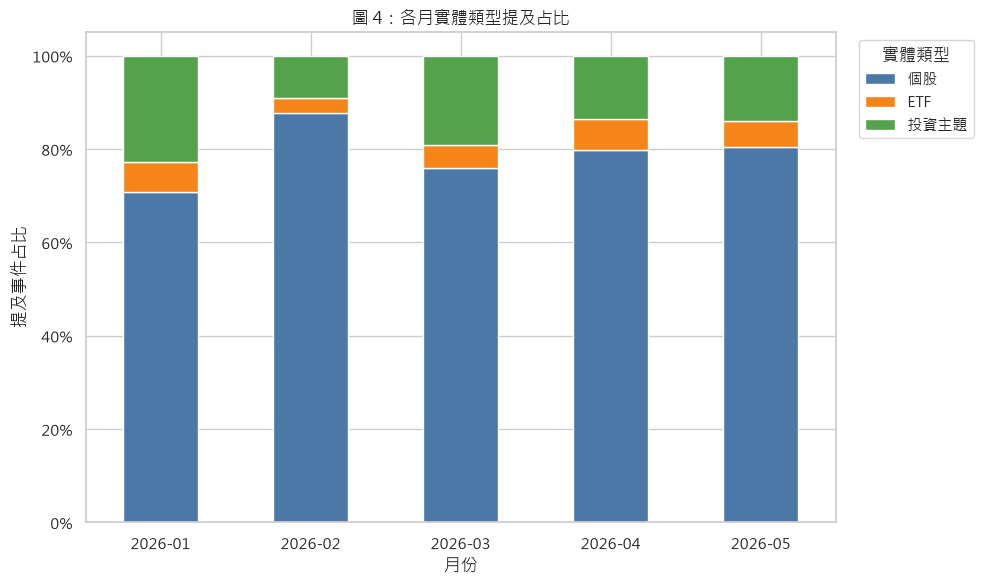

entity_type     stock       ETF     theme
month                                    
2026-01      0.707648  0.064860  0.227493
2026-02      0.877264  0.032193  0.090543
2026-03      0.759129  0.049968  0.190903
2026-04      0.798246  0.065789  0.135965
2026-05      0.803838  0.055437  0.140725


In [18]:
monthly_type_counts = pd.crosstab(mention_events["month"], mention_events["entity_type"])
monthly_type_counts = monthly_type_counts.reindex(columns=TYPE_ORDER, fill_value=0)
monthly_type_share = monthly_type_counts.div(monthly_type_counts.sum(axis=1), axis=0)

ax = monthly_type_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[TYPE_COLOR[t] for t in TYPE_ORDER],
)
ax.set_xlabel("月份")
ax.set_ylabel("提及事件占比")
ax.set_title("圖 4：各月實體類型提及占比")
ax.legend([TYPE_LABEL[t] for t in TYPE_ORDER], title="實體類型", bbox_to_anchor=(1.02, 1))
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.xticks(rotation=0)
save_and_show("figure_4_monthly_entity_type_share.png")

print(monthly_type_share)



本節比較不同月份樣本中，個股、ETF 與投資主題三類實體的提及占比，以觀察討論焦點是否出現明顯變化。

從結果來看，各月份的討論結構大致穩定，個股在所有月份中皆為主要討論對象，占比介於 70.8% 至 87.7% 之間。這表示即使月份不同，法人買賣超相關討論仍主要圍繞個別股票展開。

ETF 的提及占比在各月份皆偏低，約介於 3.2% 至 6.6% 之間，未呈現明顯上升或下降趨勢。因此，若僅從實體類型占比觀察，無法支持「討論熱點逐漸轉向 ETF」的說法。

投資主題的占比則有一定波動，其中 1 月為 22.7%、3 月為 19.1%，相對較高；2 月則降至 9.1%。然而，4 月與 5 月分別為 13.6% 與 14.1%，並未延續明確的上升或下降方向。因此，投資主題雖在部分月份較突出，但整體未呈現穩定的崛起或降溫趨勢。

整體而言，本分析**未觀察到明顯的實體類型熱點轉移**。討論結構在各月份中大致維持「個股為主、投資主題為輔、ETF 占比較低」的型態。這表示若要進一步觀察熱點轉移，應改以具體主題或共現群聚作為單位，而非僅使用個股、ETF、投資主題三種大型分類。


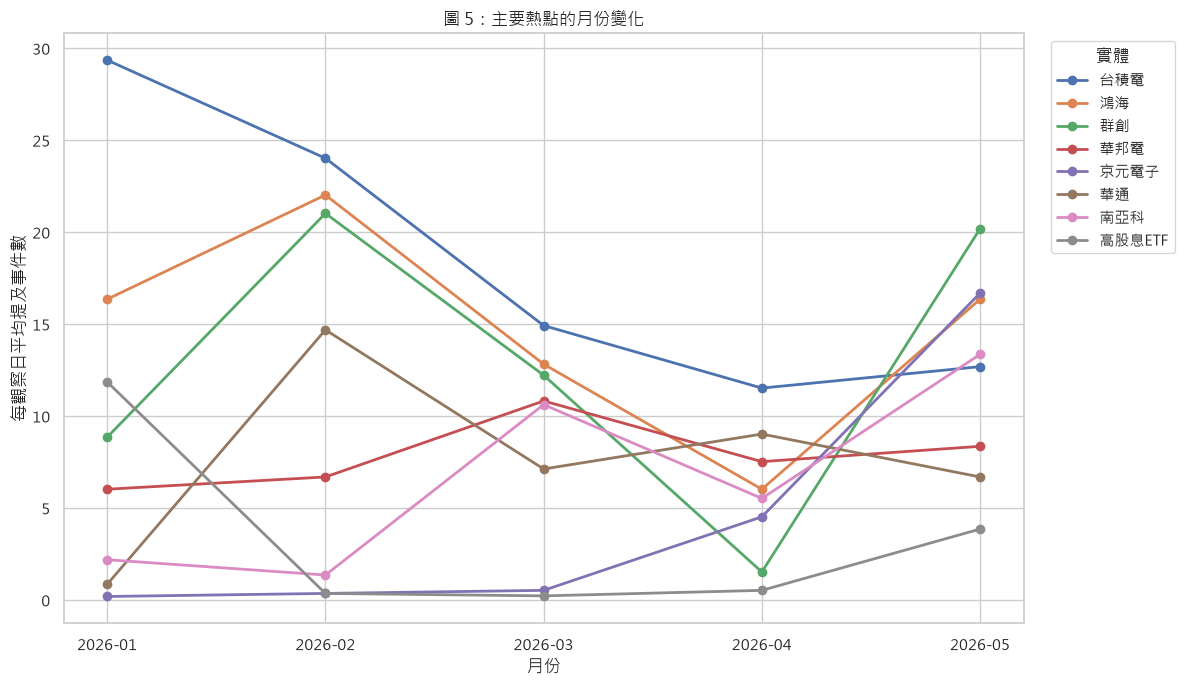

stock_name        台積電         鴻海         群創        華邦電       京元電子         華通  \
month                                                                          
2026-01     29.333333  16.333333   8.833333   6.000000   0.166667   0.833333   
2026-02     24.000000  22.000000  21.000000   6.666667   0.333333  14.666667   
2026-03     14.900000  12.800000  12.200000  10.800000   0.500000   7.100000   
2026-04     11.500000   6.000000   1.500000   7.500000   4.500000   9.000000   
2026-05     12.666667  16.333333  20.166667   8.333333  16.666667   6.666667   

stock_name        南亞科     高股息ETF  
month                             
2026-01      2.166667  11.833333  
2026-02      1.333333   0.333333  
2026-03     10.600000   0.200000  
2026-04      5.500000   0.500000  
2026-05     13.333333   3.833333  


In [19]:
# 圖 5：主要熱點的月份變化。
# 選取一半「整體聲量最高」、一半「每觀察日聲量變動範圍最大」的實體。
monthly_entity_counts = pd.crosstab(mention_events["month"], mention_events["stock_name"])
all_months = monthly_observation_days.index
monthly_entity_counts = monthly_entity_counts.reindex(all_months, fill_value=0)
daily_avg = monthly_entity_counts.div(monthly_observation_days["觀察日數"], axis=0)

half = max(1, HOTSPOT_COUNT // 2)
highest_volume = list(entity_mentions.head(half).index)
largest_change = list((daily_avg.max() - daily_avg.min()).sort_values(ascending=False).index)
selected_hotspots = highest_volume.copy()
for entity in largest_change:
    if entity not in selected_hotspots:
        selected_hotspots.append(entity)
    if len(selected_hotspots) >= HOTSPOT_COUNT:
        break

hotspot_daily_avg = daily_avg[selected_hotspots]
plt.figure(figsize=(12, 7))
for entity in selected_hotspots:
    plt.plot(
        hotspot_daily_avg.index,
        hotspot_daily_avg[entity],
        marker="o",
        linewidth=2,
        label=entity,
    )
plt.xlabel("月份")
plt.ylabel("每觀察日平均提及事件數")
plt.title("圖 5：主要熱點的月份變化")
plt.legend(title="實體", bbox_to_anchor=(1.02, 1), loc="upper left")
save_and_show("figure_5_monthly_hotspots.png")
#hotspot_daily_avg.to_csv(OUTPUT_DIR / "monthly_hotspot_daily_average.csv", encoding="utf-8-sig")
print(hotspot_daily_avg)


![3481](img/3481.png) 
![2449](img/2449.png)
![2317](img/2317.png)
![2408](img/2408.png)

圖5比較主要熱門實體在不同月份的每觀察日平均提及次數。整體來看，台積電在各月份皆維持較高聲量，顯示其為法人買賣超討論中的長期核心標的。鴻海、群創、華邦電等個股也在多數月份維持一定討論度。

若觀察個別股票，群創、鴻海、南亞科與京元電子在 5 月樣本中的提及熱度相對較高。對照其股價走勢圖，部分個股在 5 月也出現股價走強或接近波段高點的現象，顯示社群討論熱度與市場價格表現可能存在同步變化。

然而，本研究並未納入完整股價報酬率、成交量或新聞事件資料，因此無法判斷是股價上漲帶動討論增加，或是社群討論反映投資人對相關標的的關注。換言之，此處只能作為探索性觀察，不能解釋為因果關係。

整體而言，圖5並未呈現所有主題一致性的熱點轉移，但部分個股在特定月份出現明顯升溫，例如群創、南亞科與京元電子在 5 月的提及次數上升。這表示熱點變化較可能發生在個別標的層級，而不是整體實體類型層級。

### 7. 法人交易標的與 PTT 討論比較

#### 圖 6：法人 ETF 標的占比與 PTT ETF 討論占比

比較：外資、投信、PTT的ETF 提及占比

分析：

* 是否同步增加
* 是否存在落差
* 是否出現議題外溢


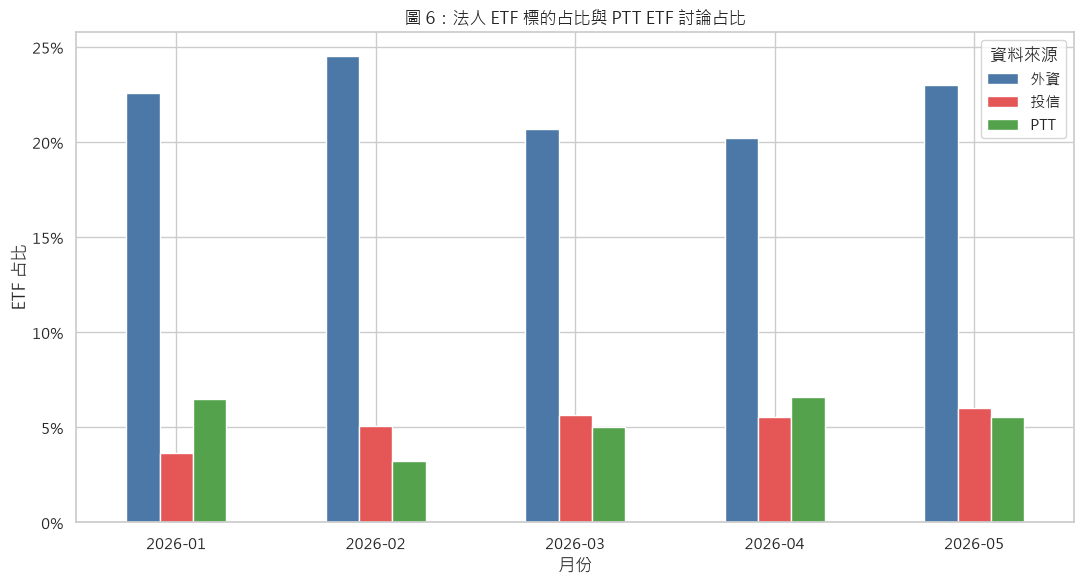

In [20]:
net_events = net.drop_duplicates(subset=["transDate", "investor", "stock_id"]).copy()
net_events["is_etf"] = net_events["entity_type"].eq("ETF")

institution_etf_share = (
    net_events.groupby(["month", "investor"])["is_etf"]
    .mean()
    .unstack("investor")
)
ptt_etf_share = (
    mention_events.assign(is_etf=mention_events["entity_type"].eq("ETF"))
    .groupby("month")["is_etf"]
    .mean()
    .rename("PTT")
)

comparison = institution_etf_share.join(ptt_etf_share, how="outer").sort_index()
comparison = comparison.reindex(columns=["外資", "投信", "PTT"])

ax = comparison.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#4C78A8", "#E45756", "#54A24B"],
)
ax.set_xlabel("月份")
ax.set_ylabel("ETF 占比")
ax.set_title("圖 6：法人 ETF 標的占比與 PTT ETF 討論占比")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(title="資料來源")
plt.xticks(rotation=0)
save_and_show("figure_6_institution_vs_ptt_etf_share.png")
#comparison.to_csv(OUTPUT_DIR / "institution_vs_ptt_etf_share.csv", encoding="utf-8-sig")


本節比較外資、投信買賣超榜單中的 ETF 標的占比，以及 PTT 討論中的 ETF 提及占比，以觀察法人交易標的與社群討論是否呈現同步變化。

從結果來看，外資 ETF 標的占比在各月份皆明顯高於投信與 PTT，約介於 20.2% 至 24.5% 之間。相較之下，投信 ETF 占比約為 3.7% 至 6.0%，PTT ETF 提及占比則約為 3.2% 至 6.6%。

此結果顯示，外資買賣超榜單中 ETF 具有相當比例，但這並未直接反映在 PTT 討論上。若 ETF 討論與外資交易標的同步，理論上外資 ETF 占比較高的月份，PTT ETF 提及占比也應同步提高；但本資料中並未觀察到此現象。例如 2026 年 2 月外資 ETF 占比為 24.5%，為各月最高，但 PTT ETF 提及占比僅 3.2%，反而是各月最低。2026 年 4 月 PTT ETF 提及占比達 6.6%，但外資 ETF 占比並非最高。

因此，本研究未發現法人 ETF 標的占比與 PTT ETF 討論占比之間有明顯同步增加的關係。這表示外資是否較常交易 ETF，未必會直接轉化為社群對 ETF 的討論熱度。

另一方面，這也反映出 PTT 使用者的討論焦點仍較偏向個股與具體投資主題，而不是單純跟隨法人榜單中 ETF 標的比例變化。ETF 在外資榜單中可能是重要交易標的，但在社群討論中仍屬於相對低比例的討論對象。

### 8. 結論與限制

#### 8.1 研究問題回答

##### RQ1：哪些實體經常共同出現？

共現分析結果顯示，最常共同出現的實體配對為南亞科與華邦電，共現43次；其次為友達與群創，共現29次；台積電與鴻海共現28次，0050與台積電共現21次，南亞科與「記憶體」則共現17次。

這些高頻配對可大致分為三種類型。第一類是**同產業個股**，例如南亞科與華邦電、友達與群創；第二類是**市場代表性個股**，例如台積電與鴻海；第三類是**ETF與代表性成分股**，例如0050與台積電。

此外，南亞科、華邦電與「記憶體」，以及友達、群創與「面板」之間的連結，顯示**使用者在討論個股時，也會透過產業或投資主題組織相關資訊**。換言之，PTT使用者並非只孤立地討論單一股票，而會將相關個股、ETF與投資主題放在同一個討論脈絡中。

##### RQ2：哪些節點是共現網路的核心？

從加權度數來看，台積電是整體共現網路中最核心的節點，加權度數為126；其次為鴻海90、華邦電85、南亞科77及群創65。

台積電同時與鴻海、0050、00981A、ETF、主動式ETF、高股息ETF及其他個股產生連結，表示其不僅具有最高的提及聲量，也與最多不同類型的實體形成高強度共現。因此，台積電在網路中不只是熱門個股，也是連結權值股、ETF與投資主題的重要橋接節點。

群聚分析則辨識出四個主要社群，分別為台積電核心的權值股與ETF群聚、記憶體群聚、面板群聚及航運群聚。值得注意的是，「記憶體」的加權度數達56，在記憶體群聚中具有明顯的連結功能；「面板」也與群創、友達形成產業群聚。這表示**投資主題並非只是附帶出現的詞彙，而可能是使用者連結相關個股、理解產業關係的重要概念**。

##### RQ3：討論熱點是否出現月份變化？

從實體類型占比來看，各月份的整體討論結構**沒有出現明顯轉移**。個股在所有月份均占主要比例，約介於70.8%至87.7%；ETF占比約為3.2%至6.6%，未呈現持續上升或下降；投資主題雖有波動，但也沒有形成穩定的升溫或降溫趨勢。

因此，本研究沒有發現討論焦點由個股整體轉向ETF或投資主題的明顯結構性變化。不同月份大致維持「個股為主、投資主題為輔、ETF占比較低」的型態。

不過，在個別實體層級仍可觀察到部分熱點變化。台積電在各月份均維持相對較高的討論度，但每觀察日平均提及次數由1月的29.33次下降至4月的11.50次，5月略回升至12.67次。群創在2月與5月較受關注，5月平均每日提及20.17次；南亞科則由1月與2月的低度討論，增加至3月的10.60次及5月的13.33次；京元電子在5月亦明顯升溫，平均每日提及16.67次。

整體而言，**月份變化主要發生在特定個股**，而非個股、ETF與投資主題三種實體類型之間的全面轉移。因此，本研究只觀察到個別標的的階段性升溫與降溫，未發現一致且持續的整體熱點轉移。

#### 8.2 主要發現

本研究的主要發現可整理為以下四點。

1. **法人買賣超相關討論仍以個股為核心。**
   個股占全部提及事件的77.5%，明顯高於投資主題的17.1%與ETF的5.4%。這表示PTT使用者在相關文章下，主要仍以具體股票作為討論單位。

2. **共現關係呈現明顯的產業與投資脈絡。**
   南亞科與華邦電、友達與群創等同產業個股形成高強度連結；0050與台積電則呈現ETF與代表性成分股的關係。使用者會透過產業、ETF及權值股等脈絡組織市場資訊，而非只討論單一標的。

3. **台積電是整體網路中最重要的核心與橋接節點。**
   台積電的提及事件數、度數及加權度數皆為最高，並同時連結權值股、ETF與投資主題。相較於只具有高聲量的個股，台積電更具有跨群聚的網路位置。

4. **投資主題在網路中具有連結個股的功能。**
   「記憶體」與「面板」分別嵌入相關產業群聚，顯示投資主題不是獨立於個股之外的討論，而是使用者用來連結公司、辨識產業及理解市場的重要框架。

5. **月份間未出現明顯的整體熱點轉移，但部分個股有階段性升溫。**
   個股、ETF與投資主題的整體占比大致穩定，未發現討論結構由個股轉向ETF的現象。不過，群創、南亞科與京元電子等標的在特定月份的平均提及次數明顯提高，顯示社群注意力的變化較可能發生在個別標的層級。

此外，外資買賣超榜單中的ETF占比約為20.2%至24.5%，明顯高於投信的3.7%至6.0%及PTT討論的3.2%至6.6%。各月份亦未呈現明顯同步變化，例如2月外資ETF占比最高，但PTT的ETF提及占比反而最低。因此，本研究未發現法人ETF交易比例與PTT ETF討論熱度之間具有明顯同步關係，也未觀察到清楚的ETF議題外溢現象。

#### 8.3 研究限制

本研究有以下限制。

1. **樣本交易日有限且不連續。**
   資料僅涵蓋2026年1月至5月間的27個特定交易日，無法完整代表各月份或2026年全年狀況。因此，月份分析僅反映已蒐集樣本中的相對變化，不能解釋為完整市場趨勢。

2. **資料來源無法代表整個PTT Stock板。**
   本研究使用的留言來自外資與投信買賣超文章下方，結果反映的是法人買賣超資訊情境中的討論，不宜推論為整個PTT Stock板的整體關注情形。

3. **共現關係不代表因果或實際產業關係。**
   本研究將同一位使用者在同一天共同提及兩個實體定義為共現。共現只表示兩者在討論中同時出現，不能證明一個實體造成另一個實體受到關注，也不能直接證明兩家公司具有業務、價格或投資上的關係。

4. **無法判斷討論熱度與股價變化的方向。**
   部分個股在特定月份同時出現討論升溫與股價走強，但本研究未系統性納入股價報酬率、成交量及新聞事件，因此無法判斷是股價變化帶動討論，或社群注意力反映市場動向。

5. **投資主題分類包含不同性質的概念。**
   `entity_type`中的投資主題同時包含產業名稱、ETF類型及投資風格，例如記憶體、面板、主動式ETF與高股息ETF。不同概念的語意層次並不完全相同，可能影響類型占比與群聚結果的解釋。

6. **網路圖受到篩選門檻影響。**
   為了提高圖形可讀性，本研究只保留達到一定提及次數及共現次數的節點與連線。因此，低頻但可能具有意義的實體關係未必會出現在最終網路中。

#### 8.4 總結

本研究發現，法人買賣超相關的PTT討論雖以個股為主，但使用者並非孤立地理解每一檔股票，而會透過產業、ETF與市場代表性個股建立討論關係。共現網路中，台積電是連結多種討論脈絡的核心節點；記憶體、面板與航運則形成具有產業特徵的群聚。

在月份變化方面，本研究未發現討論結構由個股明顯轉向ETF或投資主題，但部分個股在特定月份出現階段性升溫。因此，相較於大型實體分類的整體轉移，PTT社群的熱點變化更可能表現在具體股票與產業題材的變動上。

整體而言，共現分析補充了單純聲量排名無法呈現的關係結構，顯示社群媒體中的投資討論不只是「哪些股票受到關注」，也包含使用者「如何將不同股票與投資概念連結起來」。
